# 58 - Code Challenge: Kaiming vs Xavier, 100 Runs Each

**Section:** Weight Initialization | **Prereqs:** `Weight Initialization/CodeChallenge_Weight_Inits.ipynb` | **Next:** `Convolution and transformations/Convolutions_in_Code.ipynb`

The methodologically important notebook in this section. Two initialisation
schemes, 100 training runs each, comparing *distributions* rather than single
numbers.

**Why 100 runs.** A single run confounds the thing you are testing with
initialisation luck. Earlier notebooks in this course compare one run against one
run - which is how you end up confidently reporting a difference that is noise.
Repeat, plot both distributions, compare the means, and if you want to be strict,
run a t-test (`Math.ipynb` has one).

**How to read the plots.** The horizontal dashed lines are the means. If the two
clouds of points overlap heavily and the means are close, there is no real
difference - regardless of which one is nominally higher. A difference only
counts when it is large relative to the spread.

**The expected result:** ReLU networks are supposed to prefer Kaiming (it is
derived for exactly this case). If Xavier wins here, the honest reading is that
the difference is small on a 3-layer network - initialisation scheme matters far
more as depth grows.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# https://archive.ics.uci.edu/

!pip install ucimlrepo

In [ ]:
# Wine quality with extreme total_sulfur_dioxide values removed.
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

y = y[X['total_sulfur_dioxide']<200]
X = X[X['total_sulfur_dioxide']<200]

cols = X.columns
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


In [ ]:
y

,quality
0,5
1,5
2,5
3,6
4,5
...,...
6492,6
6493,5
6494,6
6495,7


In [ ]:
# Binarise at quality > 5.
y = (y['quality']>5).astype(int)

In [ ]:
y = y.rename("bool")

In [ ]:
# Reshape to (N,1) for BCEWithLogitsLoss.
y = y.to_numpy().reshape(-1,1)

In [ ]:
y.shape

(6086, 1)

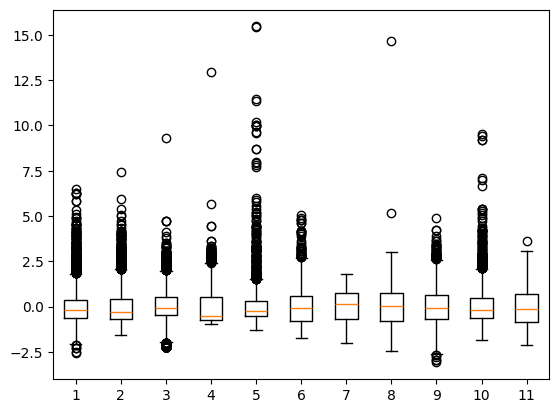

In [ ]:
# Split first, then fit the scaler on train and transform test. Correct order.

X_train, X_test, Y_train, Y_test = train_test_split(X,y,test_size=0.2,shuffle=True)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

plt.boxplot(X_train);

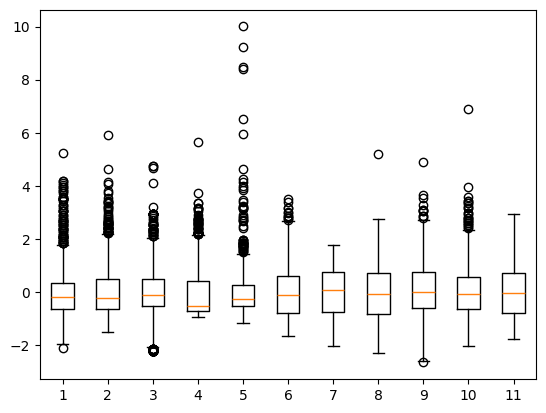

In [ ]:
plt.boxplot(X_test);

In [ ]:
# Tensors on GPU, batches of 256.
X_train = torch.tensor(X_train, dtype= torch.float, device='cuda')
X_test = torch.tensor(X_test, dtype= torch.float, device='cuda')

Y_train = torch.tensor(Y_train, dtype= torch.float, device='cuda')
Y_test = torch.tensor(Y_test, dtype= torch.float, device='cuda')

train_dataset = TensorDataset(X_train, Y_train)
test_dataset = TensorDataset(X_test, Y_test)

bs= 256

train_loader = DataLoader(train_dataset, batch_size=bs,shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [ ]:
# 11 -> 64 -> 64 -> 1 with ReLU, raw logit out.
class classifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(11,64),
        nn.ReLU(),
        nn.Linear(64,64),
        nn.ReLU(),
        nn.Linear(64,1)
    )

  def forward(self,x):
    return self.model(x)

In [ ]:
# One function, two conditions: apply Xavier explicitly, or leave PyTorch's
# default (Kaiming-uniform) in place.
# The model is built fresh inside the function, so the 100 repeats below are
# genuinely independent - the flaw that undermined the activation-function
# comparison in Metaparameters/ is avoided here.
def train_model(XaivierBool):

  model = classifier()

  if XaivierBool:
    for pname, y in model.named_parameters():
      if "weight" in pname:
        nn.init.xavier_normal_(y)

  lr = 1e-4
  epochs = 250

  lossFunc = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  test_acc = []
  train_acc = []
  losses = []


  for epoch in range(epochs):

    model.to('cuda').train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(
        ((yhat > 0).float() == y).float().mean().item() * 100
      )

    # Training Metrics
    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Validation
    model.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      test_acc.append(
        ((model(X) > 0).float() == Y).float().mean().item() * 100
      )
    # Print Data
    # if epoch % 25 == 0 or epoch == epochs-1:
    #   if XaivierBool:
    #    print(f'Xaivier | Epoch {epoch} | Loss : {losses[epoch]} | Train Accuracy: {train_acc[epoch]} | Val Accuracy : {test_acc[epoch]}')
    #   else:
    #     print(f'Kaiming | Epoch {epoch} | Loss : {losses[epoch]} | Train Accuracy: {train_acc[epoch]} | Val Accuracy : {test_acc[epoch]}')


  print()

  return test_acc[-1], train_acc[-1]


In [ ]:
# 200 training runs. The slow cell of the section, and the reason the result is
# worth believing: with 100 samples per condition, the mean is a real estimate
# rather than one draw.
Xaivier_test = []
Kaiming_test = []

Xaivier_train = []
Kaiming_train = []

for i in range(100):
  test_acc, train_acc = train_model(True)
  Xaivier_test.append(test_acc)
  Xaivier_train.append(train_acc)

  test_acc, train_acc = train_model(False)
  Kaiming_test.append(test_acc)
  Kaiming_train.append(train_acc)


  print(f'Test {i+1}/100 complete!')






Test 1/100 complete!


Test 2/100 complete!


Test 3/100 complete!


Test 4/100 complete!


Test 5/100 complete!


Test 6/100 complete!


Test 7/100 complete!


Test 8/100 complete!


Test 9/100 complete!


Test 10/100 complete!


Test 11/100 complete!


Test 12/100 complete!


Test 13/100 complete!


Test 14/100 complete!


Test 15/100 complete!


Test 16/100 complete!


Test 17/100 complete!


Test 18/100 complete!


Test 19/100 complete!


Test 20/100 complete!


Test 21/100 complete!


Test 22/100 complete!


Test 23/100 complete!


Test 24/100 complete!


Test 25/100 complete!


Test 26/100 complete!


Test 27/100 complete!


Test 28/100 complete!


Test 29/100 complete!


Test 30/100 complete!


Test 31/100 complete!


Test 32/100 complete!


Test 33/100 complete!


Test 34/100 complete!


Test 35/100 complete!


Test 36/100 complete!


Test 37/100 complete!


Test 38/100 complete!


Test 39/100 complete!


Test 40/100 complete!


Test 41/100 complete!


Test 42/100 complete!



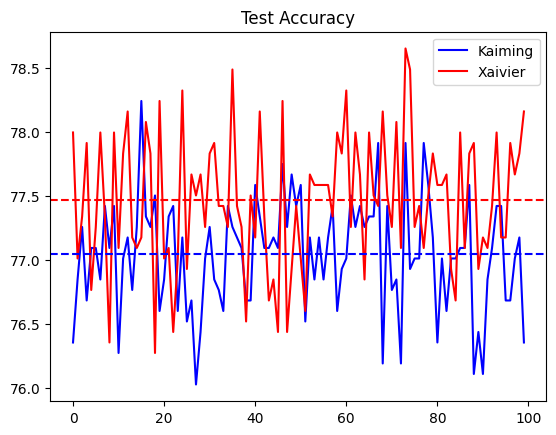

In [ ]:
# Test accuracy per run, with each condition's mean as a dashed line.
# Read the SPREAD first: if the clouds overlap heavily, the gap between the
# means is not a real effect. This is the plot every architecture comparison in
# the course should have had.
plt.plot(Kaiming_test,'b', label='Kaiming');
plt.plot(Xaivier_test,'r', label='Xaivier')
plt.axhline(y=np.mean(Kaiming_test), color='b', linestyle='--',)
plt.axhline(y=np.mean(Xaivier_test), color='r', linestyle='--')
plt.title("Test Accuracy")
plt.legend();

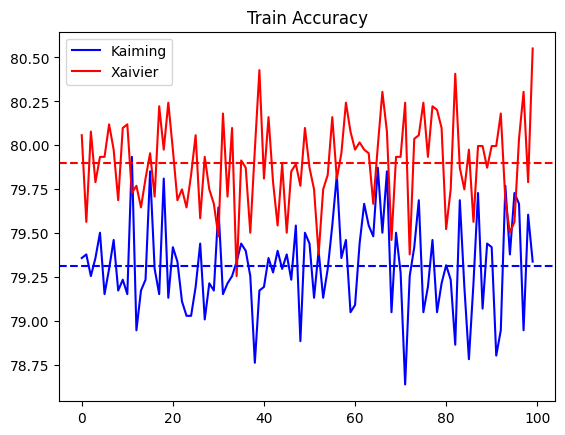

In [ ]:
# The same for train accuracy. A scheme that wins on train but not on test is
# fitting faster, not generalising better.
plt.plot(Kaiming_train,'b', label='Kaiming');
plt.plot(Xaivier_train,'r', label='Xaivier')
plt.axhline(y=np.mean(Kaiming_train), color='b', linestyle='--',)
plt.axhline(y=np.mean(Xaivier_train), color='r', linestyle='--')
plt.title("Train Accuracy")
plt.legend();

This notebook demonstrated the process of building and evaluating a simple neural network classifier for predicting wine quality. After loading and preprocessing the Wine Quality dataset, including standardizing features and converting the target to a binary classification problem, the data was prepared for a PyTorch model.

A key part of the experiment involved comparing two common weight initialization strategies: Xavier (normal) and Kaiming (PyTorch's default for ReLU layers). The neural network was trained 100 times for each initialization method, and the training and testing accuracies were recorded.

The results, as visualized in the plots, indicate that Xavier initialization generally led to higher average training and testing accuracies compared to the default Kaiming initialization for this specific model architecture and dataset. This suggests that for this particular setup, Xavier initialization might contribute to better model performance.